In [4]:
import jiwer
import pandas as pd
import numpy as np
from pathlib import Path
from openai import OpenAI
from bs4 import BeautifulSoup
import time
import json
import re

In [5]:
client = OpenAI(base_url="http://localhost:11434/v1", api_key="ollama")
MODEL = "llama3.1:8b"

resp = client.chat.completions.create(
    model=MODEL,
    messages=[{"role": "user", "content": "Say hello in one sentence."}],
    max_tokens=50,
)
print(f"Ollama ({MODEL}) is running: {resp.choices[0].message.content}")

YOLO_CLASS_MAP = {
    3: "GraphicZone",
    4: "GraphicZone-Decoration",
    6: "GraphicZone-Head",
    12: "MainZone-Head",
    16: "MainZone-P",
    18: "MainZone-Sp",
    22: "NumberingZone",
}

PAGE_WIDTH = 1559
PAGE_HEIGHT = 2088

Ollama (llama3.1:8b) is running: Hello! How are you today?


In [6]:
def parse_alto_xml(xml_path):
    def extract_box_geometry(tag):
        required = ("HPOS", "VPOS", "WIDTH", "HEIGHT")
        if not all(attr in tag.attrs for attr in required):
            return None

        hpos = float(tag["HPOS"])
        vpos = float(tag["VPOS"])
        width = float(tag["WIDTH"])
        height = float(tag["HEIGHT"])
        return hpos, vpos, hpos + width, vpos + height

    with open(xml_path, "r", encoding="utf-8") as f:
        soup = BeautifulSoup(f, "xml")

    tag_map = {}
    for tag in soup.find_all("OtherTag"):
        if tag.get("TYPE") == "region":
            tag_map[tag["ID"]] = tag["LABEL"]

    boxes = []
    for block in soup.find_all("TextBlock"):
        tag_ref = block.get("TAGREFS", "")
        label = tag_map.get(tag_ref, "Unknown")

        strings = []
        for s in block.find_all("String"):
            geometry = extract_box_geometry(s)
            if geometry is None:
                continue

            x_min, y_min, x_max, y_max = geometry
            strings.append({
                "content": s.get("CONTENT", ""),
                "x_min": x_min,
                "y_min": y_min,
                "x_max": x_max,
                "y_max": y_max,
            })

        block_geometry = extract_box_geometry(block)
        if block_geometry is None:
            if not strings:
                continue
            x_min = min(s["x_min"] for s in strings)
            y_min = min(s["y_min"] for s in strings)
            x_max = max(s["x_max"] for s in strings)
            y_max = max(s["y_max"] for s in strings)
        else:
            x_min, y_min, x_max, y_max = block_geometry

        full_text = " ".join(s["content"] for s in strings if s["content"])

        boxes.append({
            "label": label,
            "x_min": x_min,
            "y_min": y_min,
            "x_max": x_max,
            "y_max": y_max,
            "strings": strings,
            "text": full_text,
        })
    return boxes


def parse_yolo_txt(txt_path, img_w=PAGE_WIDTH, img_h=PAGE_HEIGHT):
    boxes = []
    with open(txt_path, "r") as f:
        for line in f:
            parts = line.strip().split()
            if len(parts) < 5:
                continue
            class_id = int(parts[0])
            cx, cy, w, h = float(parts[1]), float(parts[2]), float(parts[3]), float(parts[4])
            x_min = (cx - w / 2) * img_w
            y_min = (cy - h / 2) * img_h
            x_max = (cx + w / 2) * img_w
            y_max = (cy + h / 2) * img_h
            label = YOLO_CLASS_MAP.get(class_id, f"class_{class_id}")
            boxes.append({
                "label": label,
                "x_min": x_min,
                "y_min": y_min,
                "x_max": x_max,
                "y_max": y_max,
            })
    return boxes


print("Parsing functions defined.")

Parsing functions defined.


In [7]:
def compute_iou(box_a, box_b):
    x1 = max(box_a["x_min"], box_b["x_min"])
    y1 = max(box_a["y_min"], box_b["y_min"])
    x2 = min(box_a["x_max"], box_b["x_max"])
    y2 = min(box_a["y_max"], box_b["y_max"])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area_a = (box_a["x_max"] - box_a["x_min"]) * (box_a["y_max"] - box_a["y_min"])
    area_b = (box_b["x_max"] - box_b["x_min"]) * (box_b["y_max"] - box_b["y_min"])
    union = area_a + area_b - inter
    return inter / union if union > 0 else 0.0


def match_boxes(gt_boxes, pred_boxes, iou_threshold=0.5):
    iou_matrix = np.zeros((len(gt_boxes), len(pred_boxes)))
    for i, gt in enumerate(gt_boxes):
        for j, pred in enumerate(pred_boxes):
            iou_matrix[i, j] = compute_iou(gt, pred)

    matched = []
    used_gt = set()
    used_pred = set()

    while True:
        if iou_matrix.size == 0:
            break
        max_idx = np.unravel_index(np.argmax(iou_matrix), iou_matrix.shape)
        max_iou = iou_matrix[max_idx]
        if max_iou < iou_threshold:
            break
        i, j = max_idx
        matched.append({"gt": gt_boxes[i], "pred": pred_boxes[j], "iou": max_iou})
        used_gt.add(i)
        used_pred.add(j)
        iou_matrix[i, :] = 0
        iou_matrix[:, j] = 0

    missed = [gt_boxes[i] for i in range(len(gt_boxes)) if i not in used_gt]
    false_pos = [pred_boxes[j] for j in range(len(pred_boxes)) if j not in used_pred]
    return matched, missed, false_pos


def compute_page_metrics(gt_boxes, pred_boxes, iou_threshold=0.5):
    matched, missed, false_pos = match_boxes(gt_boxes, pred_boxes, iou_threshold)
    tp = len(matched)
    fp = len(false_pos)
    fn = len(missed)
    precision = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    recall = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0.0
    mean_iou = np.mean([m["iou"] for m in matched]) if matched else 0.0
    return {
        "precision": round(precision, 4),
        "recall": round(recall, 4),
        "f1": round(f1, 4),
        "mean_iou": round(mean_iou, 4),
        "true_pos": tp,
        "false_pos": fp,
        "missed": fn,
    }


print("Detection metrics functions defined.")

Detection metrics functions defined.


In [8]:
def string_inside_box(string, box):
    cx = (string["x_min"] + string["x_max"]) / 2
    cy = (string["y_min"] + string["y_max"]) / 2
    return box["x_min"] <= cx <= box["x_max"] and box["y_min"] <= cy <= box["y_max"]


def compute_text_metrics_for_match(gt_box, pred_box):
    gt_strings = gt_box.get("strings", [])
    gt_text = gt_box.get("text", "")

    if not gt_text.strip():
        return {"gt_text": "", "captured_text": "", "text_cer": 0.0, "text_wer": 0.0, "capture_rate": 1.0}

    captured = [s["content"] for s in gt_strings if string_inside_box(s, pred_box)]
    captured_text = " ".join(captured)

    if not captured_text.strip():
        return {"gt_text": gt_text, "captured_text": "", "text_cer": 1.0, "text_wer": 1.0, "capture_rate": 0.0}

    cer = jiwer.cer(gt_text, captured_text)
    wer = jiwer.wer(gt_text, captured_text)
    capture_rate = len(captured) / len(gt_strings) if gt_strings else 1.0

    return {
        "gt_text": gt_text,
        "captured_text": captured_text,
        "text_cer": round(cer, 4),
        "text_wer": round(wer, 4),
        "capture_rate": round(capture_rate, 4),
    }


def compute_page_text_metrics(gt_boxes, pred_boxes, iou_threshold=0.5):
    matched, _, _ = match_boxes(gt_boxes, pred_boxes, iou_threshold)

    region_results = []
    for m in matched:
        text_metrics = compute_text_metrics_for_match(m["gt"], m["pred"])
        region_results.append({
            "label": m["gt"]["label"],
            "iou": m["iou"],
            **text_metrics,
        })

    if not region_results:
        return {"mean_text_cer": 0.0, "mean_text_wer": 0.0, "mean_capture_rate": 0.0, "region_details": []}

    with_text = [r for r in region_results if r["gt_text"].strip()]
    if not with_text:
        return {"mean_text_cer": 0.0, "mean_text_wer": 0.0, "mean_capture_rate": 1.0, "region_details": region_results}

    return {
        "mean_text_cer": round(np.mean([r["text_cer"] for r in with_text]), 4),
        "mean_text_wer": round(np.mean([r["text_wer"] for r in with_text]), 4),
        "mean_capture_rate": round(np.mean([r["capture_rate"] for r in with_text]), 4),
        "region_details": region_results,
    }


print("Text capture evaluation functions defined.")

Text capture evaluation functions defined.


In [9]:
def format_boxes_for_llm(boxes):
    lines = []
    for i, b in enumerate(boxes):
        lines.append(f"  {i+1}. [{b['label']}] x:({b['x_min']:.0f}-{b['x_max']:.0f}) y:({b['y_min']:.0f}-{b['y_max']:.0f})")
    return "\n".join(lines) if lines else "  (none)"


def extract_json(text):
    text = text.strip()
    text = re.sub(r"^```(?:json)?\s*", "", text)
    text = re.sub(r"\s*```$", "", text)
    try:
        return json.loads(text)
    except json.JSONDecodeError:
        pass
    match = re.search(r"\{[^{}]*\}", text, re.DOTALL)
    if match:
        try:
            return json.loads(match.group())
        except json.JSONDecodeError:
            pass
    raise json.JSONDecodeError("No valid JSON found", text, 0)


def llm_judge_layout(gt_boxes, pred_boxes, page_name, max_retries=3):
    gt_str = format_boxes_for_llm(gt_boxes)
    pred_str = format_boxes_for_llm(pred_boxes)

    system_prompt = (
        "You are an expert document layout analysis evaluator. "
        "You will compare predicted region bounding boxes against ground-truth regions. "
        "Respond with ONLY valid JSON using this exact schema:\n"
        '{"layout_score": <int 1-10>, "missed_regions": <int>, "extra_regions": <int>, '
        '"mislocalized_regions": <int>, "label_mismatches": <int>, "rationale": "<brief text>"}\n'
        "Scoring guide: 10 = perfect match, 7-9 = minor issues, 4-6 = significant errors, 1-3 = severe failures."
    )

    user_prompt = (
        f"Page: {page_name} (dimensions: {PAGE_WIDTH}x{PAGE_HEIGHT} pixels)\n\n"
        f"Ground-truth regions ({len(gt_boxes)} total):\n{gt_str}\n\n"
        f"Predicted regions ({len(pred_boxes)} total):\n{pred_str}\n\n"
        "Evaluate how well the predictions match the ground truth. Consider: "
        "region count accuracy, spatial overlap, label correctness, and missed/extra detections. "
        "Respond with ONLY the JSON object."
    )

    for attempt in range(max_retries):
        try:
            response = client.chat.completions.create(
                model=MODEL,
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user", "content": user_prompt},
                ],
                temperature=0.2,
                max_tokens=400,
                response_format={"type": "json_object"},
            )
            text = response.choices[0].message.content
            return extract_json(text)
        except json.JSONDecodeError as e:
            print(f"  JSON parse error on {page_name} (attempt {attempt+1}): {e}")
            continue
        except Exception as e:
            return {"layout_score": None, "error": str(e)}
    return {"layout_score": None, "error": "Failed to get valid JSON after retries"}


print("LLM judge function defined (Ollama with JSON mode).")

LLM judge function defined (Ollama with JSON mode).


In [10]:
def run_evaluation_pipeline(ref_dir, pred_dir, iou_threshold=0.5):
    results = []
    all_region_details = []
    ref_files = sorted(Path(ref_dir).glob("*.xml"))

    for ref_path in ref_files:
        page_name = ref_path.stem
        pred_path = Path(pred_dir) / f"{page_name}.txt"

        if not pred_path.exists():
            print(f"Skipping {page_name}: no prediction file found")
            continue

        print(f"Evaluating {page_name}...")
        gt_boxes = parse_alto_xml(ref_path)
        pred_boxes = parse_yolo_txt(pred_path)

        metrics = compute_page_metrics(gt_boxes, pred_boxes, iou_threshold)

        text_metrics = compute_page_text_metrics(gt_boxes, pred_boxes, iou_threshold)
        for rd in text_metrics["region_details"]:
            rd["page"] = page_name
        all_region_details.extend(text_metrics["region_details"])

        llm_result = llm_judge_layout(gt_boxes, pred_boxes, page_name)

        results.append({
            "page": page_name,
            "gt_count": len(gt_boxes),
            "pred_count": len(pred_boxes),
            **metrics,
            "mean_text_cer": text_metrics["mean_text_cer"],
            "mean_text_wer": text_metrics["mean_text_wer"],
            "mean_capture_rate": text_metrics["mean_capture_rate"],
            "llm_score": llm_result.get("layout_score"),
            "llm_missed": llm_result.get("missed_regions"),
            "llm_extra": llm_result.get("extra_regions"),
            "llm_mislocalized": llm_result.get("mislocalized_regions"),
            "llm_label_mismatches": llm_result.get("label_mismatches"),
            "llm_rationale": llm_result.get("rationale", llm_result.get("error", "")),
        })

    df = pd.DataFrame(results)
    df.to_csv("evaluation_results.csv", index=False)

    df_regions = pd.DataFrame(all_region_details)
    df_regions.to_csv("region_text_details.csv", index=False)

    return df, df_regions


df_results, df_regions = run_evaluation_pipeline("TEI_directory6", "pipeline_dist_output")

Evaluating page_0020...
Evaluating page_0021...
Evaluating page_0022...
Evaluating page_0023...
Evaluating page_0024...
Evaluating page_0025...
Evaluating page_0026...
Evaluating page_0027...
Evaluating page_0028...
Evaluating page_0029...
Evaluating page_0030...


In [11]:
print("=== Traditional Detection Metrics ===")
display(df_results[["page", "gt_count", "pred_count", "precision", "recall", "f1", "mean_iou", "true_pos", "false_pos", "missed"]])

print("\n=== Text Capture Metrics ===")
display(df_results[["page", "mean_text_cer", "mean_text_wer", "mean_capture_rate"]])

print("\n=== LLM Judge Scores ===")
display(df_results[["page", "llm_score", "llm_missed", "llm_extra", "llm_mislocalized", "llm_label_mismatches", "llm_rationale"]])

print("\n=== Region-level Text Details (first 20 rows) ===")
display(df_regions[["page", "label", "iou", "capture_rate", "text_cer", "text_wer"]].head(20))

=== Traditional Detection Metrics ===


,page,gt_count,pred_count,precision,recall,f1,mean_iou,true_pos,false_pos,missed
0,page_0020,15,15,1.0,1.0,1.0,0.9943,15,0,0
1,page_0021,11,11,1.0,1.0,1.0,0.9947,11,0,0
2,page_0022,13,13,1.0,1.0,1.0,0.9941,13,0,0
3,page_0023,12,12,1.0,1.0,1.0,0.9935,12,0,0
4,page_0024,16,16,1.0,1.0,1.0,0.9928,16,0,0
5,page_0025,11,11,1.0,1.0,1.0,0.9914,11,0,0
6,page_0026,15,15,1.0,1.0,1.0,0.9943,15,0,0
7,page_0027,14,14,1.0,1.0,1.0,0.9831,14,0,0
8,page_0028,16,16,1.0,1.0,1.0,0.9948,16,0,0
9,page_0029,15,15,1.0,1.0,1.0,0.9894,15,0,0



=== Text Capture Metrics ===


,page,mean_text_cer,mean_text_wer,mean_capture_rate
0,page_0020,0.0000,0.0000,1.0000
1,page_0021,0.0000,0.0000,1.0000
2,page_0022,0.0000,0.0000,1.0000
3,page_0023,0.0000,0.0000,1.0000
4,page_0024,0.0000,0.0000,1.0000
5,page_0025,0.0000,0.0000,1.0000
6,page_0026,0.0000,0.0000,1.0000
7,page_0027,0.0000,0.0000,1.0000
8,page_0028,0.0000,0.0000,1.0000
9,page_0029,0.0000,0.0000,1.0000



=== LLM Judge Scores ===


,page,llm_score,llm_missed,llm_extra,llm_mislocalized,llm_label_mismatches,llm_rationale
0,page_0020,8,0,0,0,0,Most regions are accurately detected with corr...
1,page_0021,8,0,0,2,0,"Most regions are correctly identified, but two..."
2,page_0022,7,0,0,0,0,"Most regions are correctly detected, but some ..."
3,page_0023,8,0,0,0,2,Most regions are accurately detected with corr...
4,page_0024,8,0,0,2,0,"Most regions are accurately detected, but two ..."
5,page_0025,8,0,0,3,2,"Most regions are correctly detected, but some ..."
6,page_0026,7,0,0,2,1,"Most regions are correctly identified, but som..."
7,page_0027,8,0,0,1,0,"Most regions are correctly detected, but one r..."
8,page_0028,8,0,0,2,2,"Most regions are accurately detected, but two ..."
9,page_0029,7,0,0,3,2,"Most regions are correctly identified, but the..."



=== Region-level Text Details (first 20 rows) ===


,page,label,iou,capture_rate,text_cer,text_wer
0,page_0020,MainZone-P,0.999066,1.0,0.0,0.0
1,page_0020,MainZone-P,0.998520,1.0,0.0,0.0
2,page_0020,MainZone-P,0.998060,1.0,0.0,0.0
3,page_0020,MainZone-Sp,0.997667,1.0,0.0,0.0
4,page_0020,MainZone-P,0.997163,1.0,0.0,0.0
5,page_0020,MainZone-P,0.997070,1.0,0.0,0.0
6,page_0020,MainZone-P,0.996488,1.0,0.0,0.0
7,page_0020,MainZone-P,0.996137,1.0,0.0,0.0
8,page_0020,MainZone-P,0.995975,1.0,0.0,0.0
9,page_0020,MainZone-Head,0.995962,1.0,0.0,0.0


c:\Users\yunsu\OneDrive\Documents\Code\OCR\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3023: RuntimeWarning: invalid value encountered in divide
  c /= stddev[:, None]
c:\Users\yunsu\OneDrive\Documents\Code\OCR\venv\Lib\site-packages\numpy\lib\_function_base_impl.py:3024: RuntimeWarning: invalid value encountered in divide
  c /= stddev[None, :]


Pearson correlation — F1 vs LLM score: nan
Pearson correlation — Mean IoU vs LLM score: -0.063


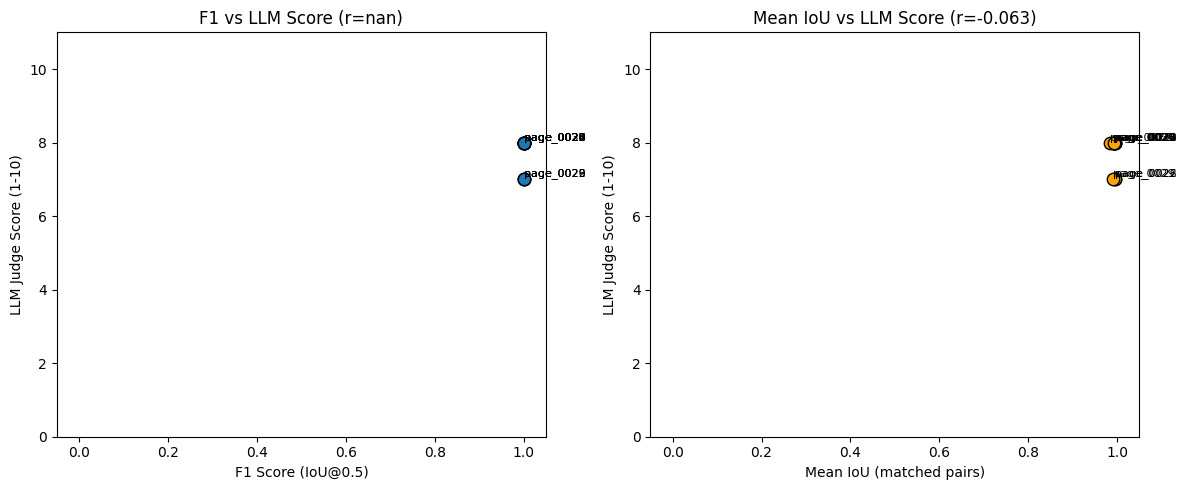

In [12]:
import matplotlib.pyplot as plt

df_valid = df_results.dropna(subset=["llm_score"]).copy()

if len(df_valid) >= 2:
    corr_f1 = df_valid["f1"].corr(df_valid["llm_score"])
    corr_iou = df_valid["mean_iou"].corr(df_valid["llm_score"])
    print(f"Pearson correlation — F1 vs LLM score: {corr_f1:.3f}")
    print(f"Pearson correlation — Mean IoU vs LLM score: {corr_iou:.3f}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(df_valid["f1"], df_valid["llm_score"], s=80, edgecolors="black")
    for _, row in df_valid.iterrows():
        axes[0].annotate(row["page"], (row["f1"], row["llm_score"]),
                         fontsize=8, ha="left", va="bottom")
    axes[0].set_xlabel("F1 Score (IoU@0.5)")
    axes[0].set_ylabel("LLM Judge Score (1-10)")
    axes[0].set_title(f"F1 vs LLM Score (r={corr_f1:.3f})")
    axes[0].set_xlim(-0.05, 1.05)
    axes[0].set_ylim(0, 11)

    axes[1].scatter(df_valid["mean_iou"], df_valid["llm_score"], s=80, edgecolors="black", color="orange")
    for _, row in df_valid.iterrows():
        axes[1].annotate(row["page"], (row["mean_iou"], row["llm_score"]),
                         fontsize=8, ha="left", va="bottom")
    axes[1].set_xlabel("Mean IoU (matched pairs)")
    axes[1].set_ylabel("LLM Judge Score (1-10)")
    axes[1].set_title(f"Mean IoU vs LLM Score (r={corr_iou:.3f})")
    axes[1].set_xlim(-0.05, 1.05)
    axes[1].set_ylim(0, 11)

    plt.tight_layout()
    plt.savefig("correlation_plots.png", dpi=150)
    plt.show()
else:
    print("Not enough valid LLM scores to compute correlation.")

In [13]:
print("=== Aggregate Metrics ===")
print(f"Mean F1:           {df_results['f1'].mean():.3f}")
print(f"Mean Precision:    {df_results['precision'].mean():.3f}")
print(f"Mean Recall:       {df_results['recall'].mean():.3f}")
print(f"Mean IoU:          {df_results['mean_iou'].mean():.3f}")
print(f"Mean Text CER:     {df_results['mean_text_cer'].mean():.4f}")
print(f"Mean Text WER:     {df_results['mean_text_wer'].mean():.4f}")
print(f"Mean Capture Rate: {df_results['mean_capture_rate'].mean():.4f}")

df_valid = df_results.dropna(subset=["llm_score"]).copy()
if len(df_valid) > 0:
    print(f"Mean LLM Score:    {df_valid['llm_score'].mean():.1f} / 10")

print("\n=== Per-page Summary ===")
display(df_results[["page", "f1", "mean_iou", "mean_text_cer", "mean_capture_rate", "llm_score"]])

=== Aggregate Metrics ===
Mean F1:           1.000
Mean Precision:    1.000
Mean Recall:       1.000
Mean IoU:          0.992
Mean Text CER:     0.0023
Mean Text WER:     0.0028
Mean Capture Rate: 0.9972
Mean LLM Score:    7.7 / 10

=== Per-page Summary ===


,page,f1,mean_iou,mean_text_cer,mean_capture_rate,llm_score
0,page_0020,1.0,0.9943,0.0000,1.0000,8
1,page_0021,1.0,0.9947,0.0000,1.0000,8
2,page_0022,1.0,0.9941,0.0000,1.0000,7
3,page_0023,1.0,0.9935,0.0000,1.0000,8
4,page_0024,1.0,0.9928,0.0000,1.0000,8
5,page_0025,1.0,0.9914,0.0000,1.0000,8
6,page_0026,1.0,0.9943,0.0000,1.0000,7
7,page_0027,1.0,0.9831,0.0000,1.0000,8
8,page_0028,1.0,0.9948,0.0000,1.0000,8
9,page_0029,1.0,0.9894,0.0000,1.0000,7


---
## Section 2: OCR Text Recognition Evaluation

Evaluate and compare three OCR models against ground truth text using CER and WER.
- **Qwen3-VL-8B** (fine-tuned on CATMuS)
- **FireRed-OCR**
- **Qwen3.5-9B**

In [15]:
import json

import jiwer

import pandas as pd

import numpy as np

import matplotlib.pyplot as plt

import matplotlib.patches as mpatches




with open("results_with_gt.json", encoding='utf-8') as f:

    ocr_data = json.load(f)



MODEL_COLS = {

    "ocr_qwen3vl8b": "Qwen3-VL-8B",

    "ocr_firered":   "FireRed-OCR",

    "ocr_qwen35":    "Qwen3.5-9B",

}



print(f"Loaded {len(ocr_data)} samples")

print(f"Keys per sample: {list(ocr_data[0].keys())}")


Loaded 18 samples
Keys per sample: ['image', 'language', 'layout', 'ground_truth', 'ocr_qwen3vl8b', 'ocr_firered', 'ocr_qwen35']


In [16]:


rows = []

for entry in ocr_data:

    gt = entry.get("ground_truth", "")

    if not gt or not gt.strip():

        continue

    row = {

        "image":    entry["image"],

        "language": entry.get("language", "?"),

        "layout":   entry.get("layout", "?"),

    }

    for col, label in MODEL_COLS.items():

        pred = entry.get(col, "")

        if pred and pred.strip():

            row[f"cer_{label}"] = round(jiwer.cer(gt, pred), 4)

            row[f"wer_{label}"] = round(jiwer.wer(gt, pred), 4)

        else:

            row[f"cer_{label}"] = None

            row[f"wer_{label}"] = None

    rows.append(row)



df_ocr = pd.DataFrame(rows)

print(f"Evaluation rows: {len(df_ocr)}")

display(df_ocr.head(5))


Evaluation rows: 17


,image,language,layout,cer_Qwen3-VL-8B,wer_Qwen3-VL-8B,cer_FireRed-OCR,wer_FireRed-OCR,cer_Qwen3.5-9B,wer_Qwen3.5-9B
0,1026A428_pdf_1-510_21_png.rf.iCOgjI6TC2M2ZEJnK...,it,single_column,0.4297,0.5321,0.3191,0.4954,0.3712,0.4954
1,1026A428_pdf_1-510_23_png.rf.6Mi3Crcp9bOB6VP4S...,it,image_with_caption,0.7407,0.8000,0.7407,0.8000,0.1605,0.6000
2,Amsterdam_1644_Dirck_Pieter_Pers_33_png.rf.GFI...,nl,mixed_complex,0.9871,0.9906,0.2228,0.3790,0.6875,0.7392
3,Amsterdam_1657_ca__Cornelis_Danckerts_28_png.r...,nl,text_heavy_structured,0.5795,0.7070,0.0992,0.3114,0.0942,0.4432
4,Augsburg_1760_ca__Georg_Hertel_34_png.rf.u8hZX...,de,image_with_caption,0.4952,0.8857,0.5095,0.8000,0.5190,0.8857


In [17]:


summary_rows = []

for col, label in MODEL_COLS.items():

    cer_col = f"cer_{label}"

    wer_col = f"wer_{label}"

    valid = df_ocr.dropna(subset=[cer_col])

    summary_rows.append({

        "Model":        label,

        "N (valid)": len(valid),

        "Mean CER":  round(valid[cer_col].mean(), 4),

        "Median CER": round(valid[cer_col].median(), 4),

        "Mean WER":  round(valid[wer_col].mean(), 4),

        "Median WER": round(valid[wer_col].median(), 4),

        "Char Accuracy": round(1 - valid[cer_col].mean(), 4),

    })



df_summary = pd.DataFrame(summary_rows).set_index("Model")

print("=== OCR Model Comparison ===")

display(df_summary)

df_summary.to_csv("ocr_model_comparison.csv")

print("Saved → ocr_model_comparison.csv")


=== OCR Model Comparison ===


,N (valid),Mean CER,Median CER,Mean WER,Median WER,Char Accuracy
Model,,,,,,
Qwen3-VL-8B,16,0.6899,0.6601,0.7668,0.8429,0.3101
FireRed-OCR,16,0.4017,0.2288,0.5778,0.4447,0.5983
Qwen3.5-9B,16,0.4845,0.2784,0.6200,0.5244,0.5155


Saved → ocr_model_comparison.csv


In [20]:


cer_cols = [f"cer_{label}" for label in MODEL_COLS.values()]

display_cols = ["image", "language"] + cer_cols

df_display = df_ocr[display_cols].copy()

def safe_best(row):

    valid = row.dropna()

    return valid.idxmin().replace("cer_", "") if not valid.empty else None

df_display["best_model"] = df_display[cer_cols].apply(safe_best, axis=1)

print("=== Per-image CER (lower is better) ===")

display(df_display)


=== Per-image CER (lower is better) ===


,image,language,cer_Qwen3-VL-8B,cer_FireRed-OCR,cer_Qwen3.5-9B,best_model
0,1026A428_pdf_1-510_21_png.rf.iCOgjI6TC2M2ZEJnK...,it,0.4297,0.3191,0.3712,FireRed-OCR
1,1026A428_pdf_1-510_23_png.rf.6Mi3Crcp9bOB6VP4S...,it,0.7407,0.7407,0.1605,Qwen3.5-9B
2,Amsterdam_1644_Dirck_Pieter_Pers_33_png.rf.GFI...,nl,0.9871,0.2228,0.6875,FireRed-OCR
3,Amsterdam_1657_ca__Cornelis_Danckerts_28_png.r...,nl,0.5795,0.0992,0.0942,Qwen3.5-9B
4,Augsburg_1760_ca__Georg_Hertel_34_png.rf.u8hZX...,de,0.4952,0.5095,0.5190,Qwen3-VL-8B
5,Augsburg_1760_ca__Georg_Hertel_50_png.rf.CXBkC...,la,1.5039,1.4341,2.3566,FireRed-OCR
6,Delft_1743-50_Hubert_Korneliszoon_Poot_22_png....,nl,0.9766,0.0517,0.0560,FireRed-OCR
7,Delft_1743-50_Hubert_Korneliszoon_Poot_34_png....,nl,0.3747,0.1103,0.0943,Qwen3.5-9B
8,London_1709_P__Tempest_21_png.rf.hWnSf09xgY5t6...,en,0.9000,0.9000,1.0500,Qwen3-VL-8B
9,London_1709_P__Tempest_34_png.rf.7072iFCXso3wE...,en,0.4888,0.0527,0.0314,Qwen3.5-9B


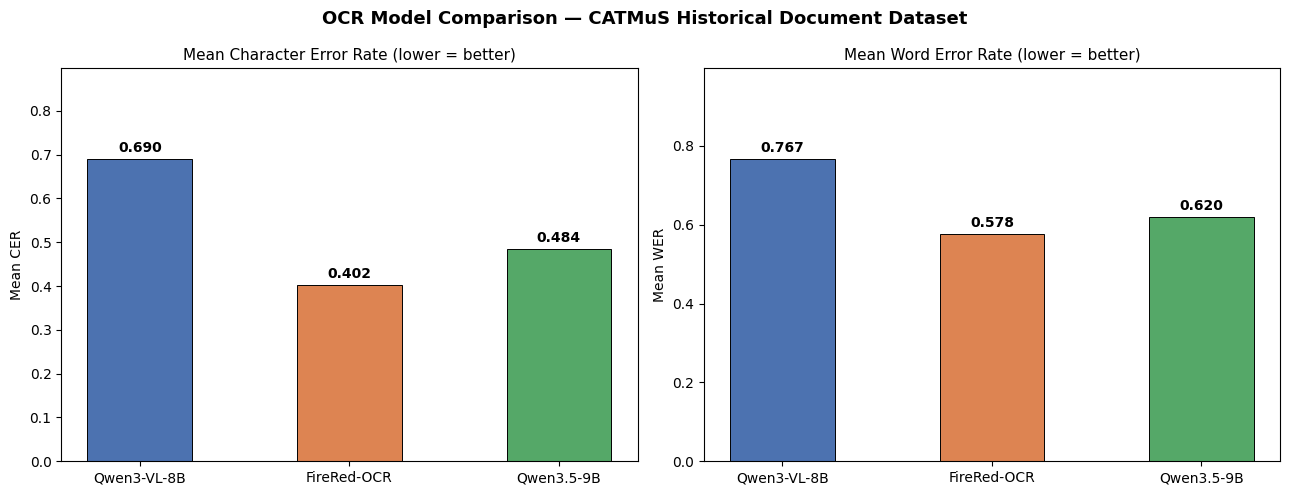

Saved → ocr_model_bar_chart.png


In [21]:


labels  = df_summary.index.tolist()

x       = np.arange(len(labels))

width   = 0.35

colors  = ["#4C72B0", "#DD8452", "#55A868"]



fig, axes = plt.subplots(1, 2, figsize=(13, 5))

fig.suptitle("OCR Model Comparison — CATMuS Historical Document Dataset", fontsize=13, fontweight="bold")



for ax, metric, title in [

    (axes[0], "Mean CER",  "Mean Character Error Rate (lower = better)"),

    (axes[1], "Mean WER",  "Mean Word Error Rate (lower = better)"),

]:

    bars = ax.bar(x, df_summary[metric], width=0.5, color=colors, edgecolor="black", linewidth=0.7)

    ax.set_xticks(x)

    ax.set_xticklabels(labels, fontsize=10)

    ax.set_ylabel(metric)

    ax.set_title(title, fontsize=11)

    ax.set_ylim(0, min(1.0, df_summary[metric].max() * 1.3))

    for bar, val in zip(bars, df_summary[metric]):

        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01,

                f"{val:.3f}", ha="center", va="bottom", fontsize=10, fontweight="bold")



plt.tight_layout()

plt.savefig("ocr_model_bar_chart.png", dpi=150, bbox_inches="tight")

plt.show()

print("Saved → ocr_model_bar_chart.png")


C:\Users\yunsu\AppData\Local\Temp\ipykernel_21072\48252937.py:12: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True,


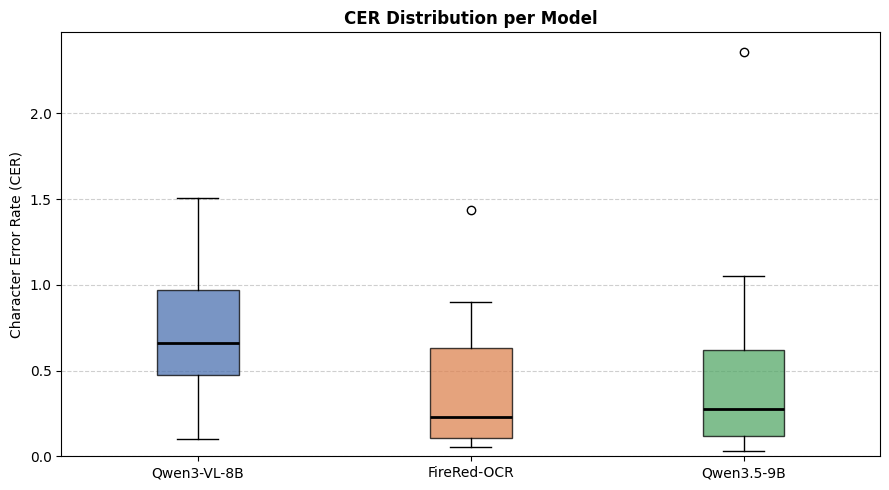

Saved → ocr_cer_boxplot.png


In [22]:


fig, ax = plt.subplots(figsize=(9, 5))



plot_data = []

plot_labels = []

for label in MODEL_COLS.values():

    col = f"cer_{label}"

    vals = df_ocr[col].dropna().tolist()

    plot_data.append(vals)

    plot_labels.append(label)



bp = ax.boxplot(plot_data, labels=plot_labels, patch_artist=True,

                medianprops=dict(color="black", linewidth=2))

for patch, color in zip(bp["boxes"], ["#4C72B0", "#DD8452", "#55A868"]):

    patch.set_facecolor(color)

    patch.set_alpha(0.75)



ax.set_ylabel("Character Error Rate (CER)")

ax.set_title("CER Distribution per Model", fontsize=12, fontweight="bold")

ax.set_ylim(0, None)

ax.yaxis.grid(True, linestyle="--", alpha=0.6)



plt.tight_layout()

plt.savefig("ocr_cer_boxplot.png", dpi=150, bbox_inches="tight")

plt.show()

print("Saved → ocr_cer_boxplot.png")


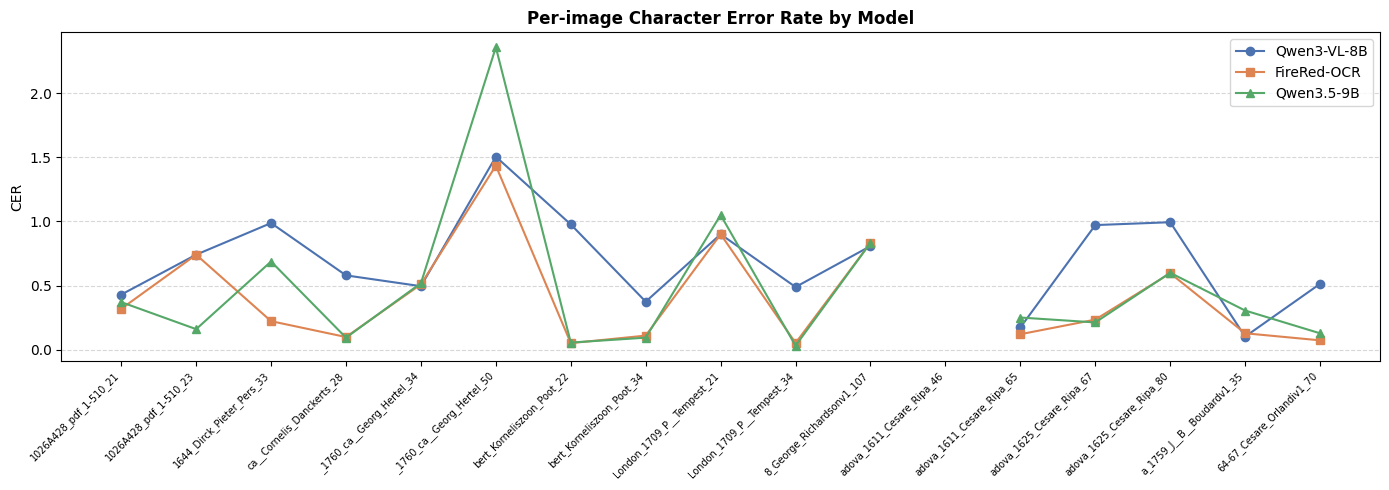

Saved → ocr_per_image_cer.png


In [23]:


fig, ax = plt.subplots(figsize=(14, 5))



x_idx = range(len(df_ocr))

x_labels = [img.split("_png")[0][-25:] for img in df_ocr["image"]]



for label, color, marker in zip(

    MODEL_COLS.values(),

    ["#4C72B0", "#DD8452", "#55A868"],

    ["o", "s", "^"],

):

    col = f"cer_{label}"

    ax.plot(list(x_idx), df_ocr[col].tolist(), label=label,

            color=color, marker=marker, linewidth=1.5, markersize=6)



ax.set_xticks(list(x_idx))

ax.set_xticklabels(x_labels, rotation=45, ha="right", fontsize=7)

ax.set_ylabel("CER")

ax.set_title("Per-image Character Error Rate by Model", fontsize=12, fontweight="bold")

ax.legend()

ax.yaxis.grid(True, linestyle="--", alpha=0.5)



plt.tight_layout()

plt.savefig("ocr_per_image_cer.png", dpi=150, bbox_inches="tight")

plt.show()

print("Saved → ocr_per_image_cer.png")


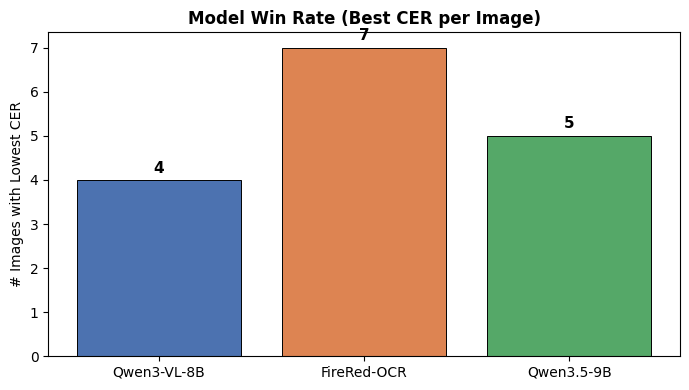

Qwen3-VL-8B    4
FireRed-OCR    7
Qwen3.5-9B     5


In [25]:


cer_cols   = [f"cer_{label}" for label in MODEL_COLS.values()]

model_names = list(MODEL_COLS.values())



def safe_winner(row):

    valid = row.dropna()

    return valid.idxmin() if not valid.empty else None

winner_col = df_ocr[cer_cols].apply(safe_winner, axis=1).map(

    {f"cer_{label}": label for label in model_names}

)

win_counts = winner_col.value_counts().reindex(model_names, fill_value=0)



fig, ax = plt.subplots(figsize=(7, 4))

colors = ["#4C72B0", "#DD8452", "#55A868"]

bars = ax.bar(model_names, win_counts, color=colors, edgecolor="black", linewidth=0.7)

for bar, val in zip(bars, win_counts):

    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,

            str(val), ha="center", va="bottom", fontsize=11, fontweight="bold")

ax.set_ylabel("# Images with Lowest CER")

ax.set_title("Model Win Rate (Best CER per Image)", fontsize=12, fontweight="bold")

plt.tight_layout()

plt.savefig("ocr_win_rate.png", dpi=150, bbox_inches="tight")

plt.show()

print(win_counts.to_string())


In [26]:


lang_groups = df_ocr.groupby("language")

lang_summary_rows = []

for lang, grp in lang_groups:

    for label in MODEL_COLS.values():

        col = f"cer_{label}"

        valid = grp[col].dropna()

        if len(valid) == 0:

            continue

        lang_summary_rows.append({"Language": lang, "Model": label,

                                   "Mean CER": round(valid.mean(), 4), "N": len(valid)})



df_lang = pd.DataFrame(lang_summary_rows)

print("=== CER by Language ===")

display(df_lang.pivot_table(index="Language", columns="Model", values="Mean CER").round(4))


=== CER by Language ===


Model,FireRed-OCR,Qwen3-VL-8B,Qwen3.5-9B
Language,,,
de,0.5095,0.4952,0.5190
en,0.5953,0.7322,0.6382
fr,0.1285,0.1024,0.3056
it,0.3475,0.6370,0.2872
la,1.4341,1.5039,2.3566
nl,0.1210,0.7295,0.2330
